# Distributional Stage-1

Does predicting *how ratings are spread* beat predicting only their mean?

| mediator | width | Stage-1 predicts |
|---|---|---|
| `Hyb 7` | 7 | per-emotion population mean |
| `Hyb_sd 14` | 14 | mean (7) + across-rater std (7) |
| `Hyb_hist 35` | 35 | 7 emotions x 5 rating bins |

Everything else is held fixed: same ridge Stage-1, same anchor C, same
validation-group hyperparameter selection. Read from
`output/raw_all_final.csv`, which contains only runs computed after both
the ratings.csv repair and the feature normalisation.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from scipy.stats import wilcoxon

SRC = '../output/raw_all_final.csv'
UNIT = ['fold', 'domain', 'user_id']

# raw mediator name -> column label in the table
COLS = {'population': 'pop',
        'identity': 'Direct',
        'emotion': 'Hyb 7',
        'emotion_sd': 'Hyb_sd 14',
        'emotion_hist': 'Hyb_hist 35'}

LABEL = {'clip': 'CLIP frozen', 'qwen8b': 'Qwen3-VL 8B',
         'clip_ft': 'CLIP-ft (score)', 'clip_ft_emo': 'CLIP-ft (emotion)',
         'qwen4b': 'Qwen3-VL 4B'}

raw = pd.read_csv(SRC, low_memory=False)
print(f'{len(raw):,} rows | backbones: {sorted(raw.backbone.unique())}')


56,502 rows | backbones: ['clip']


## Build the table


In [2]:
def build(backbone, variant='C', head='ridge'):
    """One row per support size. None if this backbone has no distribution
    run yet -- reported rather than silently skipped."""
    d = raw[(raw.backbone == backbone) & (raw.variant == variant)
            & (raw['head'] == head) & raw.mediator.isin(COLS)]
    rows = []
    for n in (10, 25, 50, 100):
        g = d[d.n_train == n]
        if g.empty:
            continue
        g = g.groupby(UNIT + ['mediator'], as_index=False)['srocc'].mean()
        p = g.pivot_table(index=UNIT, columns='mediator', values='srocc')
        if not set(COLS) <= set(p.columns):
            continue
        p = p.dropna(subset=list(COLS))

        row = {'n_train': n}
        for m, label in COLS.items():
            row[label] = p[m].mean()
        # gap = hybrid - direct, with the paired test on the same difference
        for m, tag in (('emotion', '7'), ('emotion_sd', '14'),
                       ('emotion_hist', '35')):
            row[f'gap{tag}'] = (p[m] - p['identity']).mean()
            row[f'gap{tag} p'] = wilcoxon(p[m], p['identity'])[1]
            row[f'_sig_{tag}'] = wilcoxon(p[m], p['population'])[1] < .05 \
                                 and p[m].mean() > p['population'].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index('n_train') if rows else None


## Colours

Background colour goes on the **column header cells only**. The numbers
themselves stay plain, so nothing competes with reading them.


In [3]:
# --------------------------------------------------------------
# Which header gets which background. Move a name between these two
# lists to change its colour; reorder a list to reorder the columns.
# --------------------------------------------------------------
GREY_HEADERS = ['pop', 'Direct']
BLUE_HEADERS = ['Hyb 7', 'Hyb_sd 14', 'Hyb_hist 35']

GREY_BG, BLUE_BG = '#37474f', '#1565c0'
SIG = {'Hyb 7': '7', 'Hyb_sd 14': '14', 'Hyb_hist 35': '35'}


def show(df, caption):
    from IPython.display import display

    sig = {c: df[f'_sig_{t}'] for c, t in SIG.items() if f'_sig_{t}' in df.columns}
    df = df[[c for c in df.columns if not c.startswith('_sig_')]]

    order = ([c for c in GREY_HEADERS + BLUE_HEADERS if c in df.columns]
             + [c for c in df.columns if c not in GREY_HEADERS + BLUE_HEADERS])
    df = df[order]

    styles = [
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-size', '106%'),
                   ('font-weight', '700'), ('padding-bottom', '8px'),
                   ('text-align', 'left')]},
        {'selector': 'th.col_heading',
         'props': [('padding', '6px 10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right'),
                                     ('padding', '4px 10px')]},
    ]
    for i, c in enumerate(df.columns):
        if c in GREY_HEADERS:
            bg, fg = GREY_BG, 'white'
        elif c in BLUE_HEADERS:
            bg, fg = BLUE_BG, 'white'
        else:
            bg, fg = '#eceff1', '#546e7a'
        styles.append({'selector': f'th.col_heading.col{i}',
                       'props': [('background-color', bg), ('color', fg),
                                 ('font-weight', '600')]})

    fmt = {c: ('{:+.4f}' if c.startswith('gap') and not c.endswith(' p')
               else '{:.4f}') for c in df.columns}

    sty = (df.style.format(fmt).set_caption(caption)
           .set_table_styles(styles))

    # bold a mediator's score where it beats the population model (p < .05)
    for col, flags in sig.items():
        if col in df.columns:
            sty = sty.apply(lambda s, f=flags: ['font-weight:800' if bool(v)
                                                else '' for v in f.reindex(s.index)],
                            subset=[col])
    return display(sty)


## CLIP frozen


In [4]:
t = build('clip')
show(t, 'CLIP frozen | anchor C | ridge | 3 seeds')


,pop,Direct,Hyb 7,Hyb_sd 14,Hyb_hist 35,gap7,gap7 p,gap14,gap14 p,gap35,gap35 p
n_train,,,,,,,,,,,
10,0.4159,0.4196,0.4138,0.4185,0.4128,-0.0059,0.0698,-0.0011,0.6932,-0.0068,0.2717
25,0.4159,0.4312,0.4152,0.4192,0.4247,-0.0161,0.0000,-0.0120,0.0016,-0.0065,0.0452
50,0.4159,0.4404,0.4232,0.4285,0.4347,-0.0172,0.0000,-0.0120,0.0004,-0.0057,0.0559
100,0.4159,0.4559,0.4352,0.4343,0.4420,-0.0208,0.0000,-0.0216,0.0000,-0.0139,0.0000


---
## What Stage-1 is fitted on

Stage-1 is shared: one model per fold, fitted on the training group's
images and then frozen. Its targets are per-image population quantities,
not per-user ratings. Everything below is fold 0 (4,561 images, 97
training users, 10-16 raters per image).


In [5]:
from src.data.data import CORE7, XpassDataset
from src.data.splits import V4Split
from src.config import Config

cfg = Config()
ds = XpassDataset(cfg.data_dir, first_session_only=cfg.first_session_only)
fold0 = V4Split(cfg.split_dir).load_fold(0)

rows0 = ds.df[ds.df['user_id'].isin(fold0.train_users)]
rows0 = rows0[rows0['stimulus_id'].astype(str).isin(set(map(str, fold0.giaa_images)))]

sd0 = ds.per_stimulus_spread(rows0)
hist0 = ds.per_stimulus_hist(rows0)
print(f'{len(hist0)} images, {rows0.user_id.nunique()} training users')

NICE = {'impressed':'Impressed','intellectual':'Intellectual',
        'motivated':'Motivated','amused':'Amused','nostalgic':'Nostalgic',
        'sad':'Sad','distasteful':'Distasteful'}
sd_tab = pd.DataFrame({
    'mean sd': [sd0[c].mean() for c in CORE7],
    'sd across images': [sd0[c].std() for c in CORE7],
    'min': [sd0[c].min() for c in CORE7],
    'max': [sd0[c].max() for c in CORE7]},
    index=[NICE[c] for c in CORE7])
sd_tab.style.format('{:.3f}').set_caption(
    'Across-rater sd per emotion - what the 14-d design adds')


[data] first-session only: 87836 -> 83327 rows, dropped 4509 duplicates
4561 images, 97 training users


,mean sd,sd across images,min,max
Impressed,1.061,0.182,0.373,1.676
Intellectual,1.124,0.184,0.445,1.728
Motivated,1.061,0.238,0.000,1.683
Amused,0.987,0.187,0.373,1.498
Nostalgic,1.054,0.233,0.000,1.814
Sad,0.881,0.277,0.000,1.725
Distasteful,0.941,0.282,0.000,1.785


Every emotion's sd sits near 1.0 and moves by only about 0.2 across
images. The seven extra numbers carry little variation, which is what the
14-d result reflects.


# What the distributional Stage-1 is actually fitted on.

Stage-1 is a shared component: one model per fold, fitted on the training
group's images, then frozen and used for every test user. So its targets are
population quantities, one row per image -- not per-user ratings. This script
draws them, for fold 0, so the two designs can be judged on the data rather
than on the description:

  emotion_hist  the rating histogram per emotion (7 x 5 = 35 numbers/image)
  emotion_sd    the across-rater spread per emotion (7 numbers/image)


In [ ]:
# Output: paper/figures/fig_stage1_targets.{png,pdf}
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
warnings.filterwarnings("ignore")

from src.config import Config                       # noqa: E402
from src.data.data import CORE7, XpassDataset       # noqa: E402
from src.data.splits import V4Split                 # noqa: E402

OUT = Path(__file__).resolve().parents[1] / "paper" / "figures"
NICE = {"impressed": "Impressed", "intellectual": "Intellectual",
        "motivated": "Motivated", "amused": "Amused",
        "nostalgic": "Nostalgic", "sad": "Sad", "distasteful": "Distasteful"}
BLUE, GREY = "#1565c0", "#37474f"


def main() -> None:
    cfg = Config()
    ds = XpassDataset(cfg.data_dir, first_session_only=cfg.first_session_only)
    split = V4Split(cfg.split_dir)
    fold = split.load_fold(0)

    rows = ds.df[ds.df["user_id"].isin(fold.train_users)]
    giaa = set(map(str, fold.giaa_images))
    rows = rows[rows["stimulus_id"].astype(str).isin(giaa)]

    hist = ds.per_stimulus_hist(rows)          # (n_img, 35)
    sd = ds.per_stimulus_spread(rows)          # (n_img, 7)
    n_img = len(hist)
    n_raters = rows.groupby(rows["stimulus_id"].astype(str)).size()

    print(f"fold 0 Stage-1 training set: {n_img} images, "
          f"{rows['user_id'].nunique()} training users")
    print(f"raters per image: min {n_raters.min()}, median "
          f"{int(n_raters.median())}, max {n_raters.max()}")
    print()
    print("across-rater sd per emotion (what emotion_sd predicts):")
    print(f"  {'emotion':14s} {'mean':>6s} {'sd':>6s} {'min':>6s} {'max':>6s}")
    for c in CORE7:
        v = sd[c].to_numpy(float)
        print(f"  {NICE[c]:14s} {v.mean():6.3f} {v.std():6.3f} "
              f"{v.min():6.3f} {v.max():6.3f}")

    fig = plt.figure(figsize=(11.5, 6.4))
    gs = fig.add_gridspec(2, 4, height_ratios=[1.15, 1.0], hspace=0.55, wspace=0.32)

    # --- top: the mean histogram Stage-1 is asked to predict ---------------
    for j, c in enumerate(CORE7):
        ax = fig.add_subplot(gs[0, j] if j < 4 else gs[1, j - 4])
        cols = [f"{c}_b{b}" for b in range(1, 6)]
        share = hist[cols].to_numpy(float)
        ax.bar(range(1, 6), share.mean(0), color=BLUE, alpha=.85, width=.72)
        for b in range(5):
            lo, hi = np.percentile(share[:, b], [10, 90])
            ax.plot([b + 1, b + 1], [lo, hi], color=GREY, lw=1.4, alpha=.75)
        ax.set_title(NICE[c], fontsize=10)
        ax.set_xticks(range(1, 6))
        ax.set_ylim(0, .85)
        ax.grid(axis="y", alpha=.25)
        if j in (0, 4):
            ax.set_ylabel("share of raters")
        ax.set_xlabel("rating", fontsize=8)

    # --- bottom right: the sd distribution --------------------------------
    ax = fig.add_subplot(gs[1, 3])
    ax.boxplot([sd[c].to_numpy(float) for c in CORE7],
               tick_labels=[NICE[c][:4] for c in CORE7], vert=True,
               patch_artist=True,
               boxprops=dict(facecolor="#cfd8dc", edgecolor=GREY),
               medianprops=dict(color=BLUE, lw=1.8),
               flierprops=dict(marker=".", markersize=2, alpha=.3))
    ax.set_title("across-rater sd", fontsize=10)
    ax.set_ylabel("sd")
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.grid(axis="y", alpha=.25)

    fig.suptitle(
        f"What Stage-1 is fitted on (fold 0, {n_img} images, population-level)\n"
        "bars = mean share of raters per rating; vertical line = 10th-90th "
        "percentile across images", fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, .93))

    OUT.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(OUT / f"fig_stage1_targets.{ext}", dpi=200, bbox_inches="tight")
    print(f"\nwrote {(OUT / 'fig_stage1_targets.png')}")


if __name__ == "__main__":
    main()


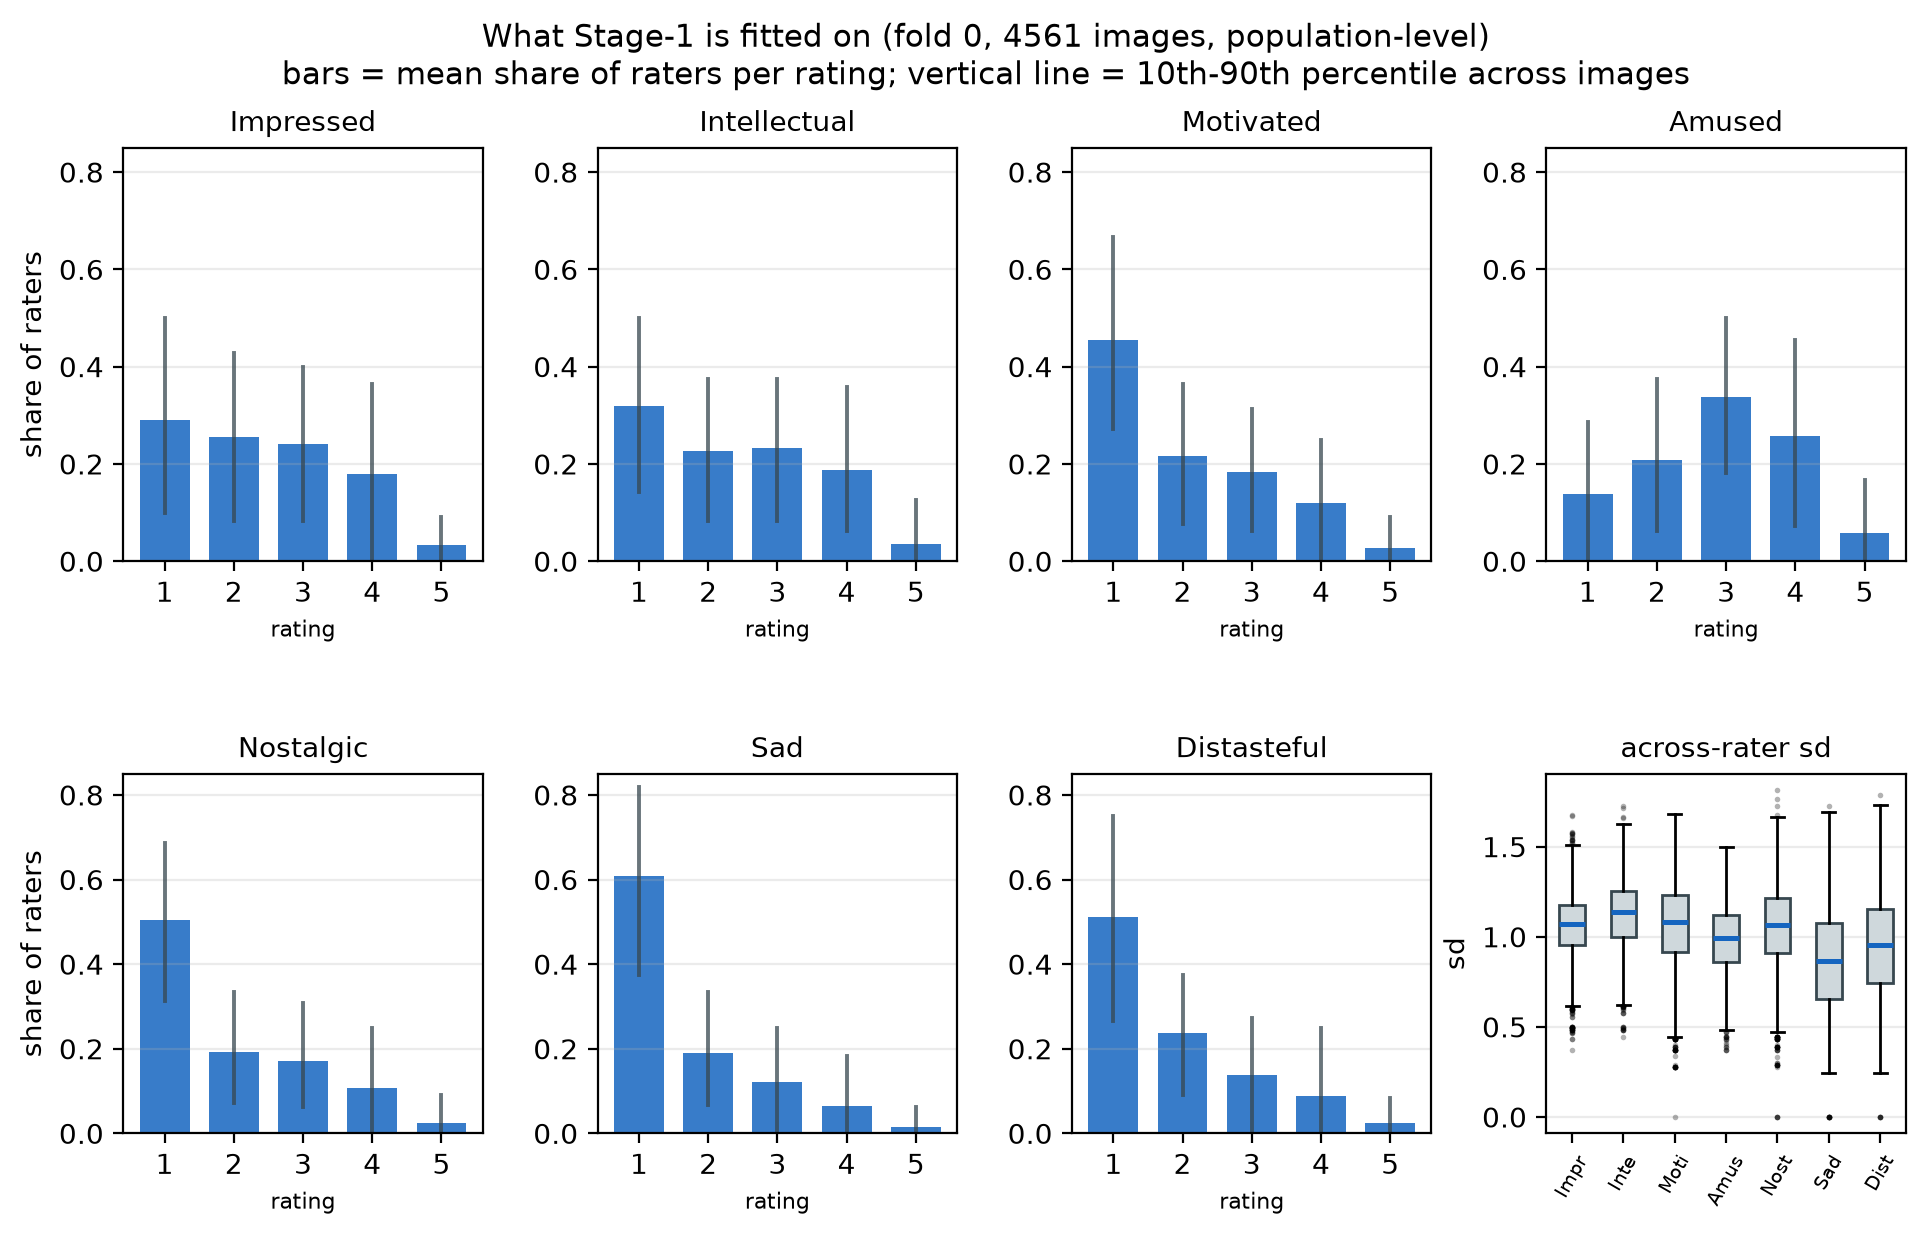

In [6]:
from IPython.display import Image
Image('../paper/figures/fig_stage1_targets.png')


---
## Which design closes the gap to Direct best

`gap = mediator - Direct`, so closer to zero is better. Ranked at each
support size.


In [7]:
def gap_ranking(backbone='clip', variant='C', head='ridge'):
    t = build(backbone, variant, head)
    if t is None:
        return None
    out = []
    for n, r in t.iterrows():
        gaps = {'Hyb 7': r['gap7'], 'Hyb_sd 14': r['gap14'],
                'Hyb_hist 35': r['gap35']}
        ranked = sorted(gaps, key=lambda k: abs(gaps[k]))
        row = {'n_train': n}
        for i, name in enumerate(ranked, 1):
            row[f'#{i}'] = f'{name}  ({gaps[name]:+.4f})'
        closed = 1 - abs(gaps[ranked[0]]) / abs(gaps['Hyb 7'])
        row['best vs 7-d'] = f'{closed:.0%} closer'
        out.append(row)
    return pd.DataFrame(out).set_index('n_train')


HEAD_STYLE = [
    {'selector': 'th.col_heading',
     'props': [('background-color', '#37474f'), ('color', 'white'),
               ('padding', '6px 10px')]},
    {'selector': 'td', 'props': [('padding', '4px 10px')]},
]

g = gap_ranking()
(g.style
 .set_caption('Gap to Direct, best first (CLIP frozen, anchor C)')
 .set_table_styles(HEAD_STYLE))


,#1,#2,#3,best vs 7-d
n_train,,,,
10,Hyb_sd 14 (-0.0011),Hyb 7 (-0.0059),Hyb_hist 35 (-0.0068),81% closer
25,Hyb_hist 35 (-0.0065),Hyb_sd 14 (-0.0120),Hyb 7 (-0.0161),60% closer
50,Hyb_hist 35 (-0.0057),Hyb_sd 14 (-0.0120),Hyb 7 (-0.0172),67% closer
100,Hyb_hist 35 (-0.0139),Hyb 7 (-0.0208),Hyb_sd 14 (-0.0216),33% closer


## Other backbones

Filled in automatically once their anchor-C distribution runs land in
`raw_all_final.csv`. Rerun the notebook; no code change needed.


In [8]:
for bb in ('qwen8b', 'clip_ft', 'clip_ft_emo', 'qwen4b'):
    t = build(bb)
    if t is None:
        print(f'{LABEL[bb]}: not run yet')
    else:
        show(t, f'{LABEL[bb]} | anchor C | ridge | 3 seeds')


Qwen3-VL 8B: not run yet
CLIP-ft (score): not run yet
CLIP-ft (emotion): not run yet
Qwen3-VL 4B: not run yet
